# AI Developer Burnout Model Training

This notebook trains the three required regression models on the burnout dataset and saves artifacts directly into `backend/artifacts/`, which is the same folder used by the Flask API and React frontend.

Models included:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

Outputs included:
- MAE, MSE, RMSE, R2 for train and test sets
- Train vs test RMSE overfitting analysis
- Feature importance
- Saved `.joblib` model files and `metadata.json`

## 1. Setup paths and imports

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# If auto-detection fails, set this manually.
# Local Windows example: MANUAL_PROJECT_ROOT = r"C:\\Users\\Yogi\\OneDrive\\Desktop\\ISM"
# Google Colab example: MANUAL_PROJECT_ROOT = "/content/ISM"
MANUAL_PROJECT_ROOT = r"C:\Users\Yogi\OneDrive\Desktop\ISM"

# Google Colab specific environment helper
IN_COLAB = 'google.colab' in sys.modules

def find_project_root():
    if MANUAL_PROJECT_ROOT:
        return Path(MANUAL_PROJECT_ROOT).expanduser().resolve()

    start = Path.cwd().resolve()
    candidates = [start, *start.parents]

    # Common locations for this project.
    if sys.platform.startswith("win"):
        candidates.append(Path(r"C:\\Users\\Yogi\\OneDrive\\Desktop\\ISM"))
    else:
        candidates.extend([Path("/content/ISM"), Path("/content")])

    # Remove duplicates while preserving order.
    candidates = list(dict.fromkeys(candidate.resolve() for candidate in candidates))
    for candidate in candidates:
        has_pipeline = (candidate / "backend" / "ml" / "pipeline.py").exists()
        has_dataset = (candidate / "employee_burnout_analysis-AI 2.xlsx").exists()
        if has_pipeline and has_dataset:
            return candidate

    searched = "\n".join(str(path) for path in candidates)
    
    if IN_COLAB:
        print("=" * 60)
        print("GOOGLE COLAB DETECTED - REQUIRED PROJECT FILES NOT FOUND!")
        print("=" * 60)
        print("Google Colab runs on a clean cloud virtual machine. To run this notebook,")
        print("you must upload the dataset and backend code files to the Colab environment.")
        print("\nChoose one of the following methods:")
        print("\n--- METHOD A: Mount Google Drive (Recommended if files are in Drive) ---")
        print("Run the following code in a new cell:")
        print("    from google.colab import drive")
        print("    drive.mount('/content/drive')")
        print("    # Then set: MANUAL_PROJECT_ROOT = '/content/drive/MyDrive/path/to/ISM'")
        print("\n--- METHOD B: Direct Upload to Colab Files Pane ---")
        print("1. Click the Folder icon on the left sidebar of Google Colab.")
        print("2. Right-click in the files pane and select 'New folder', name it 'backend'.")
        print("3. Inside 'backend', create another folder named 'ml'.")
        print("4. Upload the following files from your local computer:")
        print("   - 'employee_burnout_analysis-AI 2.xlsx' -> upload directly into '/content'")
        print("   - 'backend/ml/pipeline.py' -> upload into '/content/backend/ml/'")
        print("5. Once uploaded, rerun this cell!")
        print("=" * 60)

    raise FileNotFoundError(
        "Could not find the project root. The notebook searched these folders:\n"
        f"{searched}\n\n"
        "Set MANUAL_PROJECT_ROOT to the folder that contains both:\n"
        "- backend/ml/pipeline.py\n"
        "- employee_burnout_analysis-AI 2.xlsx\n\n"
        "If you are using Google Colab, upload/copy the full ISM project folder "
        "to /content/ISM first, then set MANUAL_PROJECT_ROOT = '/content/ISM'."
    )

PROJECT_ROOT = find_project_root()
BACKEND_DIR = PROJECT_ROOT / "backend"
DATASET_PATH = PROJECT_ROOT / "employee_burnout_analysis-AI 2.xlsx"
ARTIFACT_DIR = BACKEND_DIR / "artifacts"

if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

if not (BACKEND_DIR / "ml" / "pipeline.py").exists():
    raise FileNotFoundError(f"Missing backend pipeline at: {BACKEND_DIR / 'ml' / 'pipeline.py'}")
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing dataset at: {DATASET_PATH}")

from ml.pipeline import load_dataset, train_all, predict_burnout

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET_PATH)
print("Artifacts:", ARTIFACT_DIR)

Project root: C:\Users\Yogi\OneDrive\Desktop\ISM
Dataset: C:\Users\Yogi\OneDrive\Desktop\ISM\employee_burnout_analysis-AI 2.xlsx
Artifacts: C:\Users\Yogi\OneDrive\Desktop\ISM\backend\artifacts


## 2. Load and inspect the dataset

In [2]:
df = load_dataset(DATASET_PATH)
print(df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().to_frame("missing_values"))

(22750, 9)


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3,7.0,6.9,0.52


,dtype
Employee ID,object
Date of Joining,datetime64[ns]
Gender,object
Company Type,object
WFH Setup Available,object
Designation,int64
Resource Allocation,float64
Mental Fatigue Score,float64
Burn Rate,float64


,missing_values
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,1381
Mental Fatigue Score,2117
Burn Rate,1124


## 3. Train Linear Regression, Random Forest, and XGBoost

This calls the same production pipeline used by Flask, so the notebook and frontend stay connected through identical saved artifacts.

In [3]:
metadata = train_all(DATASET_PATH, ARTIFACT_DIR)

print("Best model:", metadata["best_model"])
print("Rows:", metadata["row_count"])
print("Features:", metadata["features"])
print("Saved artifacts:")
for path in sorted(ARTIFACT_DIR.glob("*.joblib")):
    print("-", path.name)
print("- metadata.json")

Best model: XGBoost Regressor
Rows: 22750
Features: ['Gender', 'Company Type', 'WFH Setup Available', 'Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Tenure Days']
Saved artifacts:
- linear_regression.joblib
- random_forest_regressor.joblib
- xgboost_regressor.joblib
- metadata.json


## 4. Model evaluation comparison

In [4]:
rows = []
for model_name, result in metadata["metrics"].items():
    for split in ["train", "test"]:
        rows.append({"model": model_name, "split": split, **result[split]})

metrics_df = pd.DataFrame(rows)
display(metrics_df)

test_metrics = metrics_df[metrics_df["split"] == "test"].sort_values("rmse")
display(test_metrics[["model", "mae", "mse", "rmse", "r2"]])

,model,split,mae,mse,rmse,r2
0,Linear Regression,train,0.053791,0.005101,0.071424,0.871153
1,Linear Regression,test,0.053483,0.005032,0.070940,0.867874
2,Random Forest Regressor,train,0.039330,0.002676,0.051727,0.932420
3,Random Forest Regressor,test,0.047463,0.003704,0.060863,0.902745
4,XGBoost Regressor,train,0.046054,0.003463,0.058847,0.912536
5,XGBoost Regressor,test,0.047506,0.003654,0.060451,0.904057


,model,mae,mse,rmse,r2
5,XGBoost Regressor,0.047506,0.003654,0.060451,0.904057
3,Random Forest Regressor,0.047463,0.003704,0.060863,0.902745
1,Linear Regression,0.053483,0.005032,0.070940,0.867874


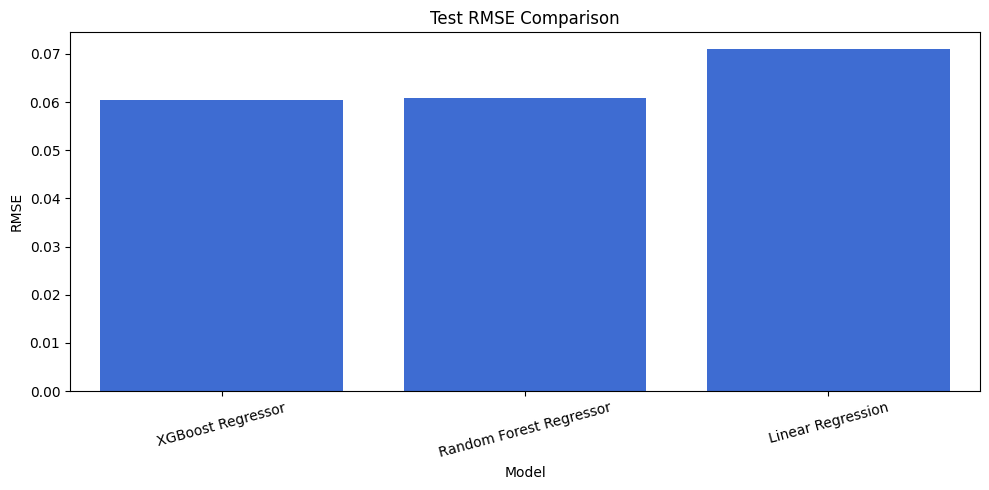

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(data=test_metrics, x="model", y="rmse", color="#2563eb")
plt.title("Test RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 5. Overfitting analysis

Overfitting is checked by comparing train RMSE against test RMSE. A large test RMSE increase is marked as `watch`.

In [6]:
overfit_rows = []
for model_name, result in metadata["metrics"].items():
    overfit_rows.append({
        "model": model_name,
        "train_rmse": result["train"]["rmse"],
        "test_rmse": result["test"]["rmse"],
        "rmse_gap": result["overfitting"]["rmse_gap"],
        "rmse_ratio": result["overfitting"]["rmse_ratio"],
        "status": result["overfitting"]["status"],
    })

overfit_df = pd.DataFrame(overfit_rows)
display(overfit_df)

,model,train_rmse,test_rmse,rmse_gap,rmse_ratio,status
0,Linear Regression,0.071424,0.070940,-0.000484,0.993223,ok
1,Random Forest Regressor,0.051727,0.060863,0.009136,1.176618,ok
2,XGBoost Regressor,0.058847,0.060451,0.001604,1.027260,ok


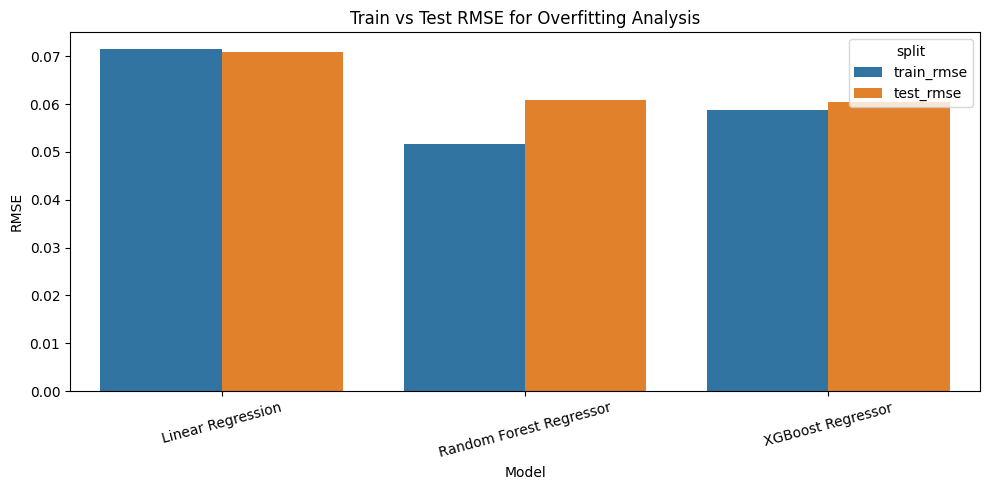

In [7]:
plot_df = overfit_df.melt(
    id_vars="model",
    value_vars=["train_rmse", "test_rmse"],
    var_name="split",
    value_name="rmse",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="model", y="rmse", hue="split")
plt.title("Train vs Test RMSE for Overfitting Analysis")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6. Feature importance for the best model

,feature,importance
0,Mental Fatigue Score,0.709902
1,Resource Allocation,0.198253
2,WFH Setup Available_No,0.030086
3,Designation,0.029301
4,WFH Setup Available_Yes,0.018491
5,Gender_Female,0.004338
6,Company Type_Service,0.002605
7,Tenure Days,0.002536
8,Gender_Male,0.002385
9,Company Type_Product,0.002105


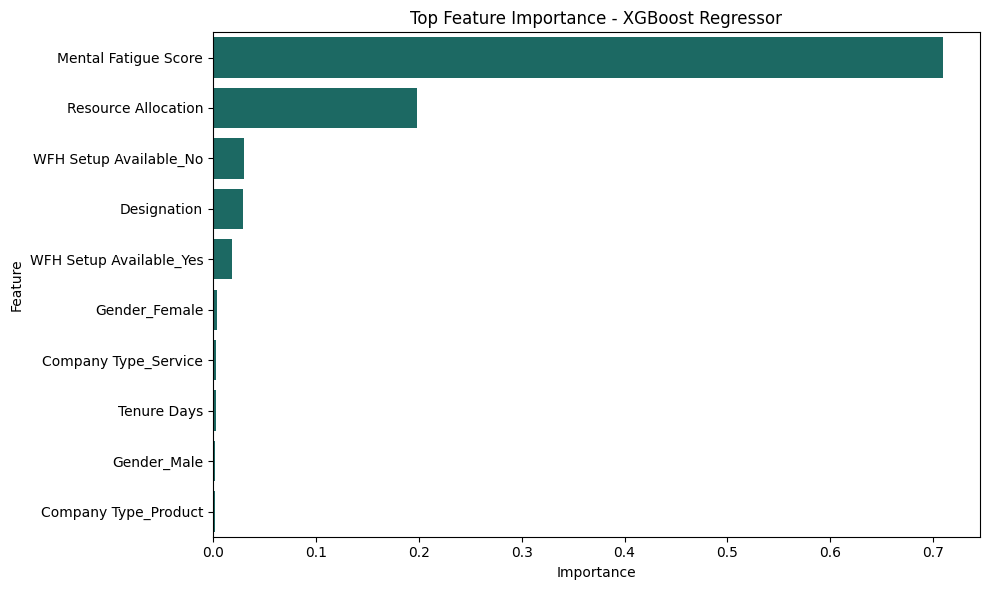

In [8]:
best_model = metadata["best_model"]
importance_df = pd.DataFrame(metadata["metrics"][best_model]["feature_importance"])
display(importance_df.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), y="feature", x="importance", color="#0f766e")
plt.title(f"Top Feature Importance - {best_model}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. Test a prediction from the saved artifact

This uses the same prediction function used by Flask. If this works, the frontend can use the model through `/api/predict`.

In [9]:
sample_payload = {
    "Gender": "Male",
    "Company Type": "Product",
    "WFH Setup Available": "Yes",
    "Designation": 2,
    "Resource Allocation": 5,
    "Mental Fatigue Score": 5.5,
    "Tenure Days": 900,
}

prediction = predict_burnout(sample_payload, ARTIFACT_DIR)
prediction

{'burn_rate': 0.4418676495552063,
 'risk_level': 'Moderate',
 'model': 'XGBoost Regressor'}

## 8. Connect to frontend

After running this notebook, start or restart Flask and React:

```powershell
cd backend
.\\.venv\\Scripts\\Activate.ps1
python run.py
```

In another terminal:

```powershell
cd frontend
npm run dev
```

Open `http://localhost:5173`. The frontend calls Flask, and Flask loads the artifacts saved by this notebook.